### Trabalho 2 - Mineração de dados
O objetivo deste trabalho é aplicar técnicas de mineração de dados para encontrar regras de associação em uma base de dados real. O foco será identificar padrões ocultos e avaliar a qualidade das regras encontradas com base em métricas estatísticas.

O dataset escolhido foi:
- Groceries_dataset.csv do Kaggle

Por ser diretamente adequado à aplicação de regras de associação e análise de cesta de compras. A base possui 38.765 registros de compras e contém informações de identificação do cliente, data da compra e descrição do produto adquirido, permitindo reconstruir transações e identificar produtos que aparecem frequentemente em conjunto

In [164]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
from pathlib import Path

caminho = Path("datas/Groceries_dataset.csv")

df_original = pd.read_csv(caminho, encoding='utf-8')

df_original.info()

display(df_original.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


#### Remover registros incompletos

Precisamos saber quem fez a compra, quando ela ocorreu e qual produto foi comprado. Por isso, removemos os registros que não possuem alguma dessas três informações.

In [165]:
dados = df_original.copy()

dados = dados.dropna(subset=["Member_number", "Date", "itemDescription"])

#### Remover produtos repetidos da mesma compra

Como as regras de associação trabalham com a presença ou ausência do item, comprar o mesmo produto duas vezes na mesma cesta não deve criar dois itens diferentes. 
Por exemplo: `milk`, `milk` e `bread` será representada por `{milk, bread}`.

In [166]:
dados = dados.drop_duplicates(subset=["Member_number", "Date", "itemDescription"])

#### Criar um identificador para cada compra

Como o dataset não possui uma coluna de identificação da transação, utilizamos a combinação do identificador do membro e da data da compra para representar cada cesta.

In [167]:
dados["transacao"] = (dados["Member_number"].astype(str)+ "_"+ dados["Date"].astype(str))

dados[["transacao", "itemDescription"]].head(5)

,transacao,itemDescription
0,1808_21-07-2015,tropical fruit
1,2552_05-01-2015,whole milk
2,2300_19-09-2015,pip fruit
3,1187_12-12-2015,other vegetables
4,3037_01-02-2015,whole milk


#### Agrupar os produtos em cestas

Agora agrupamos os produtos de cada transação em listas.

In [168]:
transacoes = (dados.groupby("transacao")["itemDescription"].apply(list).tolist())

transacoes[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

#### Quantidade de transações criadas

In [169]:
print("Quantidade de transações:", len(transacoes))

for transacao in transacoes[:5]:
    print(transacao)

Quantidade de transações: 14963
['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
['whole milk', 'pastry', 'salty snack']
['canned beer', 'misc. beverages']
['sausage', 'hygiene articles']
['soda', 'pickled vegetables']


#### Transformar as cestas em uma matriz binária

Cada coluna representa um produto, e os valores booleanos indicam sua presença ou ausência em cada transação.

In [170]:
codificador = TransactionEncoder()
matriz = codificador.fit(transacoes).transform(transacoes)

cestas = pd.DataFrame(
    matriz,
    columns=codificador.columns_
)

cestas.index = pd.Index(
    range(1, len(cestas) + 1),
    name="transacao"
)

cestas.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
transacao,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Limitação da reconstrução das cestas

Assumimos que registros com o mesmo cliente e a mesma data pertencem à mesma compra, pois o dataset não fornece um identificador explícito da transação.

#### Executar o Apriori

Primeiro, testamos o suporte de 15%. Como esse valor pode ser alto para uma base real de supermercado, também comparamos limiares menores para observar quantos itemsets frequentes são encontrados em cada caso.

In [171]:
itemsets_frequentes = apriori(cestas, min_support=0.15, use_colnames=True)

itemsets_frequentes

,support,itemsets
0,0.157923,frozenset({whole milk})


#### Definição do suporte mínimo

Testamos suportes de 1%, 2%, 3% e 5%. Apenas o suporte de 1% manteve combinações com dois ou mais produtos, então esse foi o valor escolhido para a análise.

In [172]:
resultados_limiares = []

for suporte in [0.01, 0.02, 0.03, 0.05]:
    frequentes = apriori(
        cestas,
        min_support=suporte,
        use_colnames=True
    )

    tamanhos = [len(itemset) for itemset in frequentes["itemsets"]]

    resultados_limiares.append({
        "suporte_minimo": suporte,
        "itemsets_frequentes": len(frequentes),
        "itemsets_tamanho_1": sum(tamanho == 1 for tamanho in tamanhos),
        "itemsets_tamanho_2_ou_mais": sum(tamanho >= 2 for tamanho in tamanhos)
    })

comparacao = pd.DataFrame(resultados_limiares)

comparacao

,suporte_minimo,itemsets_frequentes,itemsets_tamanho_1,itemsets_tamanho_2_ou_mais
0,0.01,69,64,5
1,0.02,38,38,0
2,0.03,27,27,0
3,0.05,11,11,0


Testamos os suportes mínimos de 1%, 2%, 3% e 5% para verificar quais valores permitiriam encontrar combinações frequentes de produtos. Observou-se que apenas o suporte de 1% gerou itemsets com dois ou mais itens. Nos demais casos, apareceram apenas itemsets unitários, impossibilitando a geração de regras de associação. Por isso, foi adotado **suporte mínimo de 1%**.

#### Definição da confiança mínima
Testamos alguns valores de confiança mínima para ver quantas regras seriam geradas.
Com 5%, apareceram 10 regras; com 7,5%, ficaram 8; e com 10%, restaram apenas 4. Por isso, escolhemos 7,5%, já que esse valor ainda mantém uma quantidade boa de regras para analisar sem deixar o filtro tão aberto.
Depois, essas regras serão comparadas também usando suporte, lift e conviction.

In [173]:
suporte_minimo = 0.01

itemsets_frequentes = apriori(
    cestas,
    min_support=suporte_minimo,
    use_colnames=True
)

In [174]:
resultados_confianca = []

for confianca in [0.05, 0.075, 0.10]:
    
    regras_teste = association_rules(
        itemsets_frequentes,
        metric="confidence",
        min_threshold=confianca
    )
    
    resultados_confianca.append({
        "confianca_minima": confianca,
        "quantidade_regras": len(regras_teste)
    })

comparacao_confianca = pd.DataFrame(resultados_confianca)

comparacao_confianca

,confianca_minima,quantidade_regras
0,0.050,10
1,0.075,8
2,0.100,4


#### Geração das regras de associação

Após a definição dos limiares de suporte e confiança, aplicamos o algoritmo Apriori para identificar os itemsets frequentes e, em seguida, gerar as regras de associação.

Foram utilizados suporte mínimo de **1%** e confiança mínima de **7,5%**. As regras obtidas serão avaliadas a partir das métricas de suporte, confiança, lift e conviction, permitindo comparar tanto a frequência das associações quanto sua força e relevância.

In [175]:
suporte_minimo = 0.01
confianca_minima = 0.075

itemsets_frequentes = apriori(
    cestas,
    min_support=suporte_minimo,
    use_colnames=True
)

regras = association_rules(
    itemsets_frequentes,
    metric="confidence",
    min_threshold=confianca_minima
)

#### Seleção das regras

Foram geradas 8 regras de associação. Como algumas delas representam a mesma combinação de produtos em sentidos opostos, foram selecionadas 5 regras evitando repetições muito semelhantes.

Um ponto que chamou nossa atenção foi que todas as regras apresentaram lift menor que 1, indicando associações negativas entre os produtos analisados.

In [176]:
regras_selecionadas = regras.loc[
    (
        regras["antecedents"].eq(frozenset({"soda"}))
        & regras["consequents"].eq(frozenset({"whole milk"}))
    )
    |
    (
        regras["antecedents"].eq(frozenset({"other vegetables"}))
        & regras["consequents"].eq(frozenset({"whole milk"}))
    )
    |
    (
        regras["antecedents"].eq(frozenset({"rolls/buns"}))
        & regras["consequents"].eq(frozenset({"other vegetables"}))
    )
    |
    (
        regras["antecedents"].eq(frozenset({"rolls/buns"}))
        & regras["consequents"].eq(frozenset({"whole milk"}))
    )
    |
    (
        regras["antecedents"].eq(frozenset({"yogurt"}))
        & regras["consequents"].eq(frozenset({"whole milk"}))
    )
]

regras_selecionadas[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "conviction"
    ]
].round(3)

,antecedents,consequents,support,confidence,lift,conviction
0,frozenset({rolls/buns}),frozenset({other vegetables}),0.011,0.096,0.786,0.971
3,frozenset({other vegetables}),frozenset({whole milk}),0.015,0.122,0.769,0.959
4,frozenset({rolls/buns}),frozenset({whole milk}),0.014,0.127,0.804,0.965
6,frozenset({soda}),frozenset({whole milk}),0.012,0.120,0.758,0.957
7,frozenset({yogurt}),frozenset({whole milk}),0.011,0.130,0.823,0.968


#### Avaliação das regras selecionadas

Foram selecionadas cinco regras evitando combinações repetidas em sentidos opostos. Todas apresentaram lift menor que 1, indicando que os produtos aparecem juntos com menos frequência do que seria esperado caso fossem independentes.

- Soda → Whole milk

A regra apresentou suporte de **1,2%**, ou seja, os dois produtos aparecem juntos em 1,2% das transações. A confiança foi de **12%**, indicando que 12% das compras com soda também continham whole milk.

O lift de **0,758** indica uma associação negativa entre os produtos. A conviction de **0,957**, também abaixo de 1, reforça que a regra não apresenta uma associação positiva.

- Other vegetables → Whole milk

Essa combinação apareceu em **1,5% das transações** e apresentou confiança de **12,2%**.

O lift foi de **0,769** e a conviction de **0,959**, indicando novamente uma associação negativa entre os produtos.

- Rolls/buns → Other vegetables

A regra apresentou suporte de **1,1%** e confiança de **9,6%**.

O lift de **0,786** indica que other vegetables aparece proporcionalmente menos nas compras que contêm rolls/buns do que na base completa. A conviction de **0,971** ficou próxima de 1, mostrando uma associação fraca.

- Rolls/buns → Whole milk

A combinação apareceu em **1,4% das transações**, com confiança de **12,7%**.

Apesar da confiança relativamente maior, o lift foi de **0,804** e a conviction de **0,965**, portanto a regra ainda apresenta associação negativa.

- Yogurt → Whole milk

A regra apresentou suporte de **1,1%** e a maior confiança entre as selecionadas, de **13%**.

Mesmo assim, o lift foi de **0,823** e a conviction de **0,968**. Isso mostra que uma confiança maior, sozinha, não significa que exista uma associação positiva entre os produtos.


Entre as regras analisadas, `other vegetables → whole milk` apresentou o maior suporte, aparecendo em 1,5% das transações. Já `yogurt → whole milk` teve a maior confiança, de 13%. Por outro lado, `soda → whole milk` apresentou o menor lift, de 0,758.

Como todas as regras tiveram lift abaixo de 1 e conviction próxima de 1, nenhuma delas apresentou uma associação positiva forte. Por isso, a análise conjunta das métricas é mais informativa do que escolher uma regra apenas pela maior confiança.

### Gráficos

#### Produtos com maior suporte

O gráfico mostra os produtos que aparecem em uma maior proporção das transações. O suporte representa a frequência de presença de cada item na base.

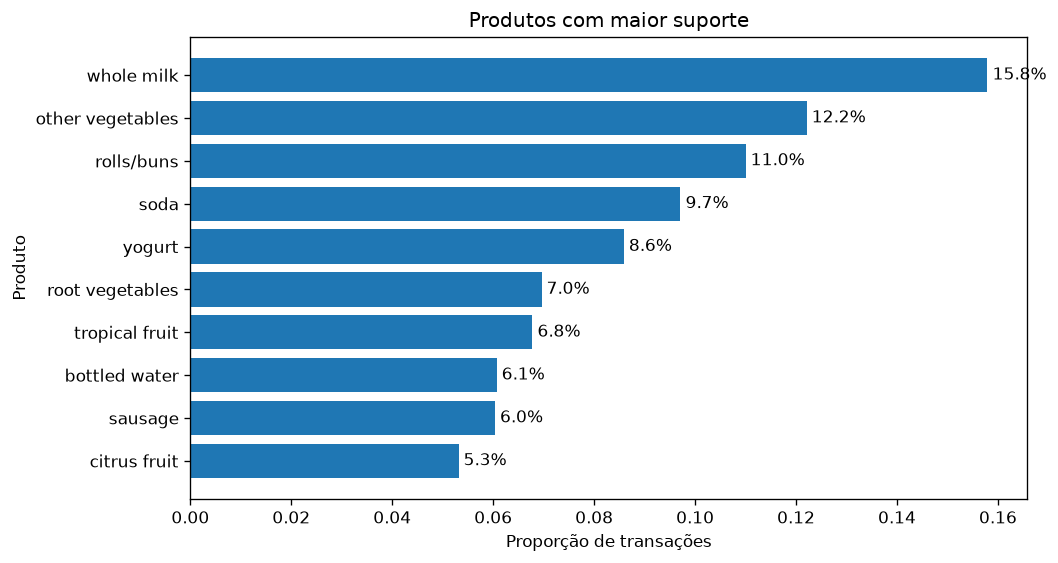

In [177]:
produtos_frequentes = itemsets_frequentes[
    itemsets_frequentes["itemsets"].apply(len) == 1
].sort_values(
    "support",
    ascending=False
)

top_produtos = produtos_frequentes.head(10).copy()

top_produtos["produto"] = [
    ", ".join(sorted(itemset))
    for itemset in top_produtos["itemsets"]
]

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)

barras = ax.barh(
    top_produtos["produto"],
    top_produtos["support"]
)

for barra in barras:
    ax.text(
        barra.get_width() + 0.001,
        barra.get_y() + barra.get_height() / 2,
        f"{barra.get_width():.1%}",
        va="center"
    )

ax.set(
    title="Produtos com maior suporte",
    xlabel="Proporção de transações",
    ylabel="Produto"
)

ax.invert_yaxis()

plt.show()

#### Confiança das regras selecionadas

O gráfico compara a confiança das cinco regras selecionadas. A confiança representa a proporção de compras com o produto antecedente que também possuem o produto consequente.

Entre as regras analisadas, `yogurt → whole milk` apresentou a maior confiança.

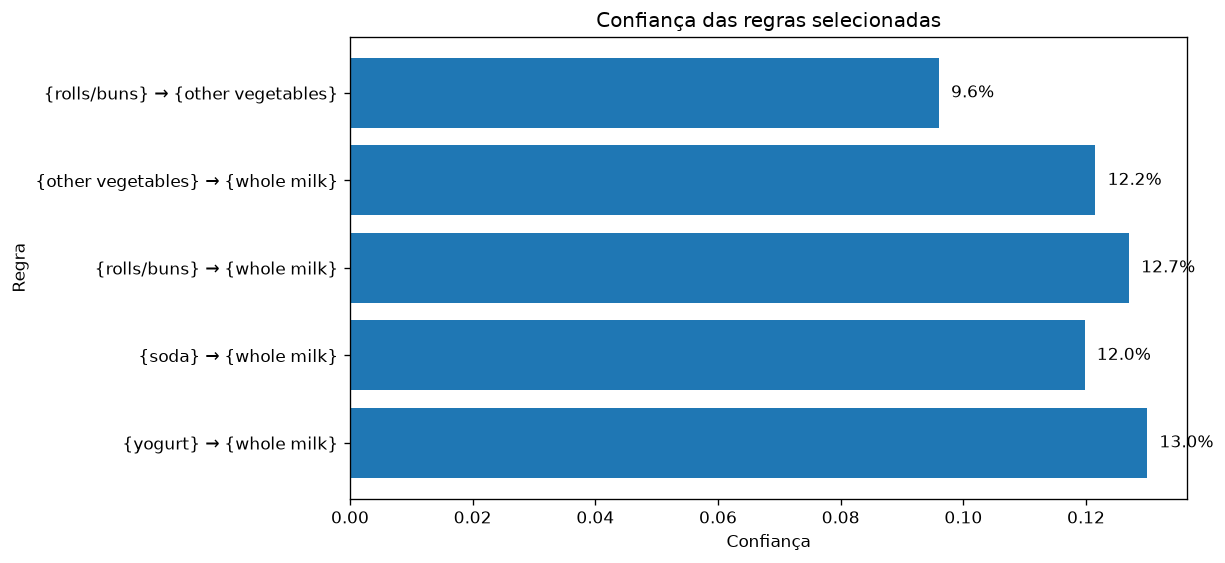

In [178]:
regras_selecionadas = regras_selecionadas.copy()

regras_selecionadas["regra"] = regras_selecionadas.apply(
    lambda r:
        "{" + ", ".join(sorted(r["antecedents"])) + "} → {"
        + ", ".join(sorted(r["consequents"])) + "}",
    axis=1
)

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)

barras = ax.barh(
    regras_selecionadas["regra"],
    regras_selecionadas["confidence"]
)

for barra in barras:
    ax.text(
        barra.get_width() + 0.002,
        barra.get_y() + barra.get_height() / 2,
        f"{barra.get_width():.1%}",
        va="center"
    )

ax.set(
    title="Confiança das regras selecionadas",
    xlabel="Confiança",
    ylabel="Regra"
)

ax.invert_yaxis()

plt.show()

#### Lift das regras selecionadas

O gráfico compara o lift das cinco regras selecionadas. A linha tracejada representa o valor 1, que corresponde à independência entre os produtos.

Todas as regras ficaram abaixo de 1, indicando associações negativas na base analisada. Entre elas, `soda → whole milk` apresentou o menor lift.

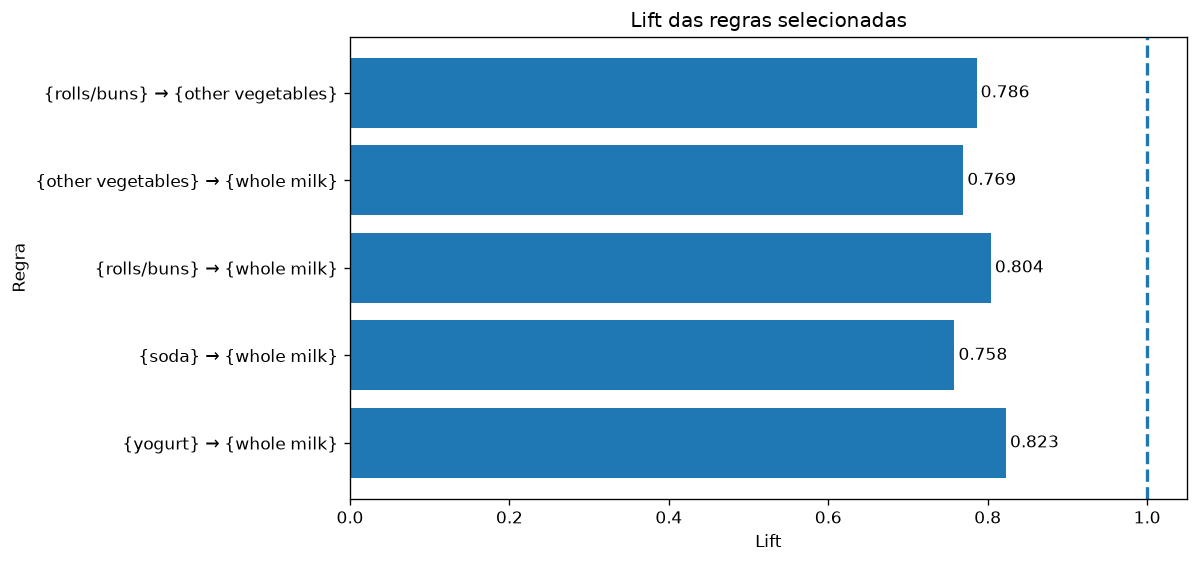

In [179]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)

barras = ax.barh(
    regras_selecionadas["regra"],
    regras_selecionadas["lift"]
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=2
)

for barra in barras:
    ax.text(
        barra.get_width() + 0.005,
        barra.get_y() + barra.get_height() / 2,
        f"{barra.get_width():.3f}",
        va="center"
    )

ax.set(
    title="Lift das regras selecionadas",
    xlabel="Lift",
    ylabel="Regra"
)

ax.invert_yaxis()

plt.show()

### Insights para o mercado

Nenhuma das regras selecionadas apresentou associação positiva entre os produtos. Na prática, isso mostra que encontrar produtos juntos em algumas compras não significa, necessariamente, que exista um padrão forte entre eles.

Esse tipo de análise pode ajudar antes de criar promoções ou recomendações de produtos, evitando decisões baseadas apenas na frequência ou na confiança das regras.

Outros fatores, como promoções, disponibilidade e período das compras, também podem influenciar esses resultados.

### Limitações

As regras representam padrões encontrados nas transações analisadas e não indicam relações de causa e efeito.

Além disso, fatores como promoções, disponibilidade dos produtos, período da compra e comportamento dos clientes podem influenciar os resultados. Por isso, as regras devem ser utilizadas como apoio para análise, e não como uma conclusão definitiva sobre o comportamento dos consumidores.

## Conclusão

Com o Apriori, foram encontradas 8 regras utilizando suporte mínimo de 1% e confiança mínima de 7,5%. Dessas, selecionamos 5 para analisar com mais detalhes.

Nenhuma apresentou lift acima de 1, então não encontramos associações positivas fortes entre os produtos selecionados. Também foi possível perceber que olhar apenas para a confiança poderia levar a uma interpretação errada, já que a regra com maior confiança ainda apresentou lift abaixo de 1.

Por isso, suporte, confiança, lift e conviction foram analisados em conjunto para interpretar melhor os resultados.